# Comparação de Classificação: Humano vs GPT 5.4 vs Gemini 3.1 Flash

Este notebook realiza uma análise comparativa entre as classificações manuais (Humano) e as predições de dois modelos de linguagem (GPT 5.4 e Gemini 3.1 Flash) baseadas em critérios de inclusão (CI1, CI2, CI3).

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from matplotlib_venn import venn3, venn2
import os

# Configurações de plotagem
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# Caminhos dos arquivos
HUMAN_PATH = "../data/articles_2.json"
GPT_PATH = "../results/gpt-5.4-prod-3-opcoes/result.json"
GEMINI_PATH = "../results/gemini-3-flash-base-2/result.json"

print("Bibliotecas carregadas e caminhos definidos.")

Bibliotecas carregadas e caminhos definidos.


## 1. Carregamento e Pré-processamento dos Dados

In [2]:
def extract_human_cis(inclusao_val):
    result = {'CI1': False, 'CI2': False, 'CI3': False}
    if not inclusao_val or pd.isna(inclusao_val):
        return result
    inclusao_val = str(inclusao_val).strip().upper()
    for ci in ['CI1', 'CI2', 'CI3']:
        if ci in inclusao_val:
            result[ci] = True
    return result

with open(HUMAN_PATH, 'r', encoding='utf-8') as f:
    human_data = json.load(f)

rows_human = []
for art in human_data:
    cis = extract_human_cis(art.get('Inclusão'))
    rows_human.append({
        'Título': art.get('Título'),
        'Autor': art.get('Autor'),
        'Ano': art.get('Ano'),
        'CI1_Human': cis['CI1'],
        'CI2_Human': cis['CI2'],
        'CI3_Human': cis['CI3']
    })

df_human = pd.DataFrame(rows_human)
print(f"Humano: {len(df_human)} registros")

Humano: 100 registros


In [3]:
def extract_llm_scores(results_path, suffix):
    with open(results_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    rows = []
    for res in data:
        meta = res.get('article_metadata', {})
        inc_res = res.get('inclusion_results', [])
        
        row = {
            'Título': meta.get('title'),
            'Autor': meta.get('author'),
            'Ano': meta.get('year')
        }
        
        for criterion in ['CI1', 'CI2', 'CI3']:
            decision = "NO"
            for item in inc_res:
                if item.get('criterion', '').upper() == criterion:
                    decision = item.get('decision', 'NO')
                    break
            row[f'{criterion}_{suffix}'] = (decision == 'YES')
            
        rows.append(row)
    return pd.DataFrame(rows)

df_gpt = extract_llm_scores(GPT_PATH, 'GPT')
df_gemini = extract_llm_scores(GEMINI_PATH, 'Gemini')

print(f"GPT 5.4: {len(df_gpt)} registros")
print(f"Gemini 3.1 Flash: {len(df_gemini)} registros")

GPT 5.4: 100 registros
Gemini 3.1 Flash: 100 registros


In [4]:
# Merge dos dataframes
df_merged = df_human.merge(df_gpt, on=['Título', 'Autor', 'Ano'], how='inner')
df_merged = df_merged.merge(df_gemini, on=['Título', 'Autor', 'Ano'], how='inner')

print(f"Total consolidado para comparação: {len(df_merged)} artigos")
df_merged.head()

Total consolidado para comparação: 100 artigos


,Título,Autor,Ano,CI1_Human,CI2_Human,CI3_Human,CI1_GPT,CI2_GPT,CI3_GPT,CI1_Gemini,CI2_Gemini,CI3_Gemini
0,QAI4ASE: Quantum artificial intelligence for a...,"De Vincentiis, Mirko; Cassano, Fabio; Pagano, ...",2022,False,False,False,False,False,False,False,False,False
1,Software Engineering Methods for Responsible A...,"Islam, Zahoor Ul",2021,True,True,True,True,True,False,True,True,False
2,Digital Twins for Software Engineering Processes,"Kimmel, Robin; Michael, Judith; Wortmann, Andr...",2025,False,False,False,False,False,False,False,False,False
3,Hyacinth macaw: a project-based learning progr...,"Fontão, Awdren; Matsubara, Edson; Mongelli, He...",2023,True,True,True,False,False,False,True,False,False
4,CAIN '22: Proceedings of the 1st International...,NaN,2022,False,False,False,True,False,True,True,False,True


## 2. Análise de Desempenho (Acertos)

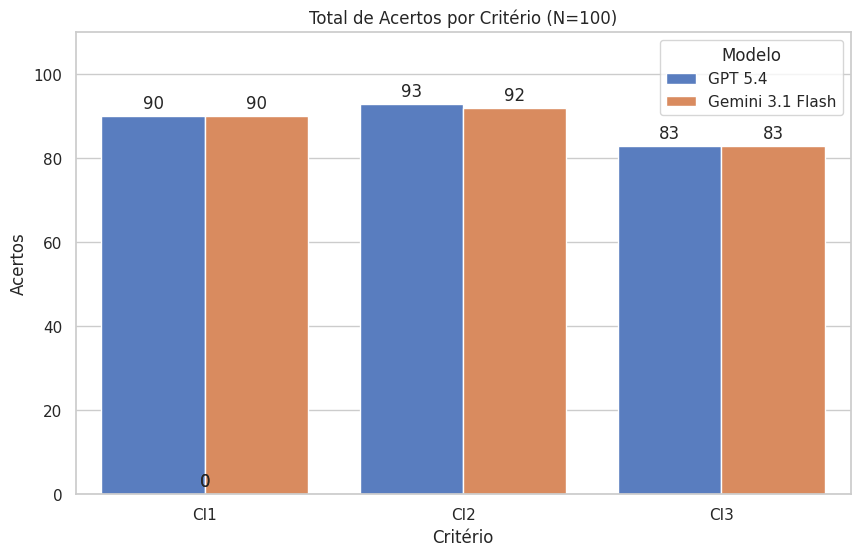

In [5]:
performance_data = []
for ci in ['CI1', 'CI2', 'CI3']:
    gpt_hits = (df_merged[f'{ci}_Human'] == df_merged[f'{ci}_GPT']).sum()
    gemini_hits = (df_merged[f'{ci}_Human'] == df_merged[f'{ci}_Gemini']).sum()
    
    performance_data.append({'Critério': ci, 'Modelo': 'GPT 5.4', 'Acertos': gpt_hits})
    performance_data.append({'Critério': ci, 'Modelo': 'Gemini 3.1 Flash', 'Acertos': gemini_hits})

df_perf = pd.DataFrame(performance_data)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Critério', y='Acertos', hue='Modelo', data=df_perf, palette='muted')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title(f'Total de Acertos por Critério (N={len(df_merged)})')
plt.ylim(0, len(df_merged) + 10)
plt.show()

## 3. Comparação de Seleção (Aceitos vs Não Aceitos)

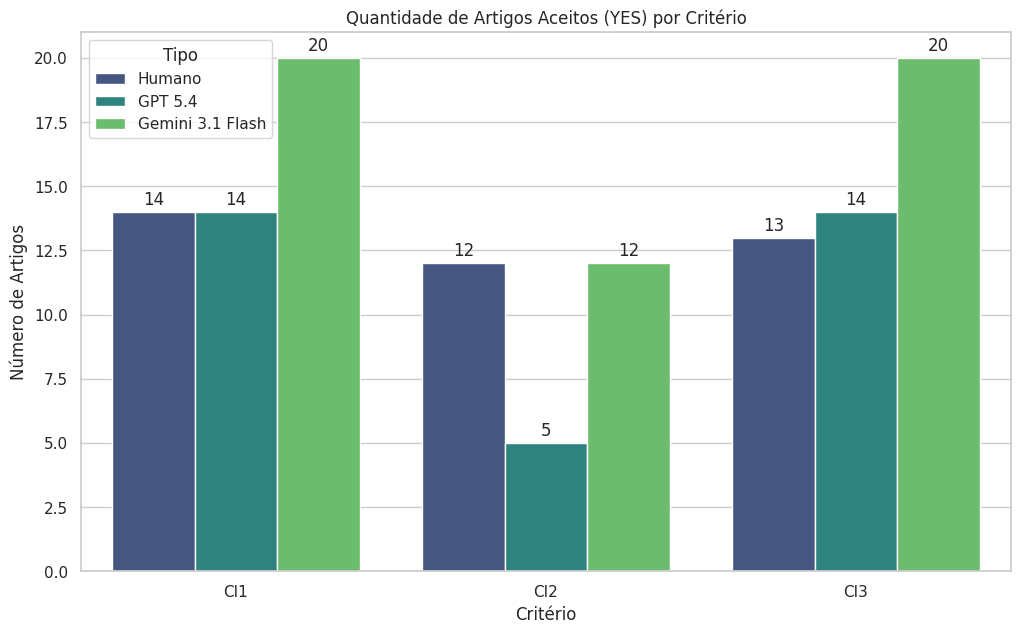

In [6]:
selection_data = []
for ci in ['CI1', 'CI2', 'CI3']:
    h_true = df_merged[f'{ci}_Human'].sum()
    gpt_true = df_merged[f'{ci}_GPT'].sum()
    gem_true = df_merged[f'{ci}_Gemini'].sum()
    
    selection_data.append({'Critério': ci, 'Tipo': 'Humano', 'Quantidade': h_true})
    selection_data.append({'Critério': ci, 'Tipo': 'GPT 5.4', 'Quantidade': gpt_true})
    selection_data.append({'Critério': ci, 'Tipo': 'Gemini 3.1 Flash', 'Quantidade': gem_true})

df_sel = pd.DataFrame(selection_data)

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Critério', y='Quantidade', hue='Tipo', data=df_sel, palette='viridis')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.0f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points')

plt.title('Quantidade de Artigos Aceitos (YES) por Critério')
plt.ylabel('Número de Artigos')
plt.show()

## 4. Diagramas de Venn (Interseção de Inclusão)

Considerando um artigo como "Incluído" se ele passar em pelo menos um critério.

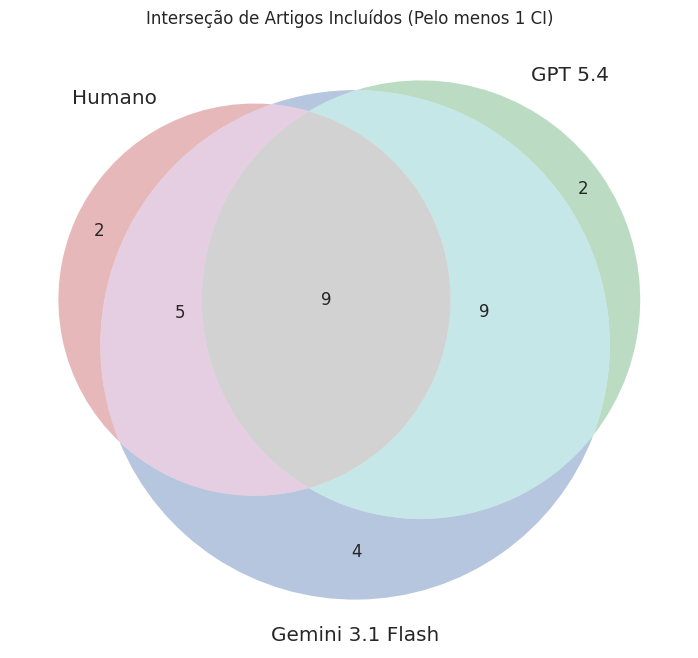

In [12]:
df_merged['Included_Human'] = df_merged[['CI1_Human', 'CI2_Human', 'CI3_Human']].any(axis=1)
df_merged['Included_GPT'] = df_merged[['CI1_GPT', 'CI2_GPT', 'CI3_GPT']].any(axis=1)
df_merged['Included_Gemini'] = df_merged[['CI1_Gemini', 'CI2_Gemini', 'CI3_Gemini']].any(axis=1)

set_h = set(df_merged[df_merged['Included_Human']].index)
set_gpt = set(df_merged[df_merged['Included_GPT']].index)
set_gem = set(df_merged[df_merged['Included_Gemini']].index)

plt.figure(figsize=(10, 8))
venn3([set_h, set_gpt, set_gem], ('Humano', 'GPT 5.4', 'Gemini 3.1 Flash'))
plt.title("Interseção de Artigos Incluídos (Pelo menos 1 CI)")
plt.show()

### 5.1 Comparação Direta: GPT 5.4 vs Gemini 3.1 Flash

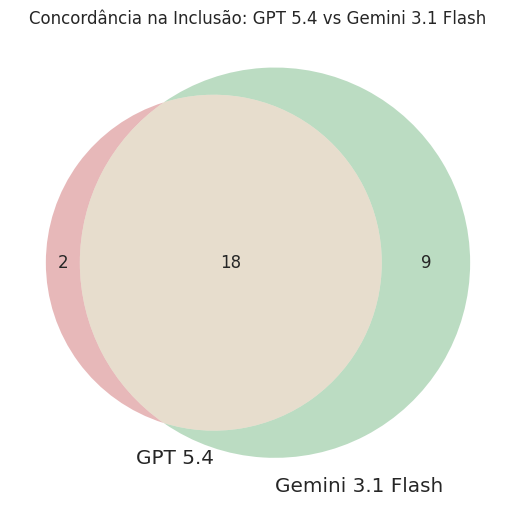

In [13]:
plt.figure(figsize=(8, 6))
venn2([set_gpt, set_gem], ('GPT 5.4', 'Gemini 3.1 Flash'))
plt.title("Concordância na Inclusão: GPT 5.4 vs Gemini 3.1 Flash")
plt.show()

### 5.2 Concordância por Critério (GPT vs Gemini)

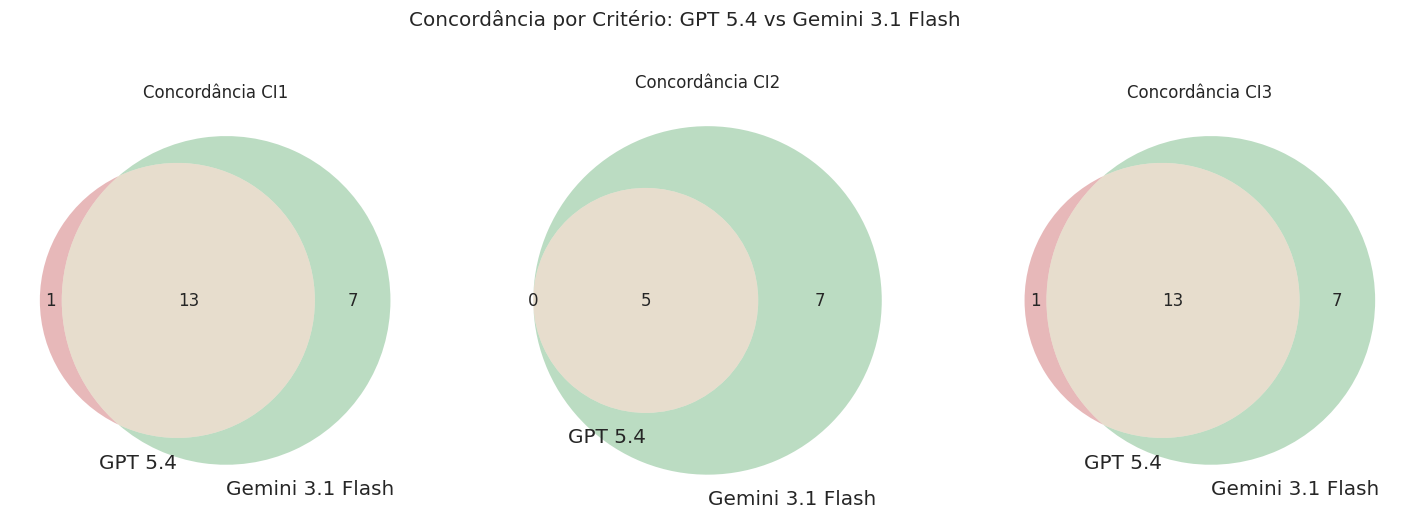

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ci in enumerate(['CI1', 'CI2', 'CI3']):
    set_gpt_ci = set(df_merged[df_merged[f'{ci}_GPT']].index)
    set_gem_ci = set(df_merged[df_merged[f'{ci}_Gemini']].index)
    venn2([set_gpt_ci, set_gem_ci], ('GPT 5.4', 'Gemini 3.1 Flash'), ax=axes[i])
    axes[i].set_title(f"Concordância {ci}")

plt.suptitle("Concordância por Critério: GPT 5.4 vs Gemini 3.1 Flash")
plt.show()

## 6. Análise de Falsos Negativos e Falsos Positivos

Vamos olhar para os casos onde os modelos divergiram do humano na inclusão final.

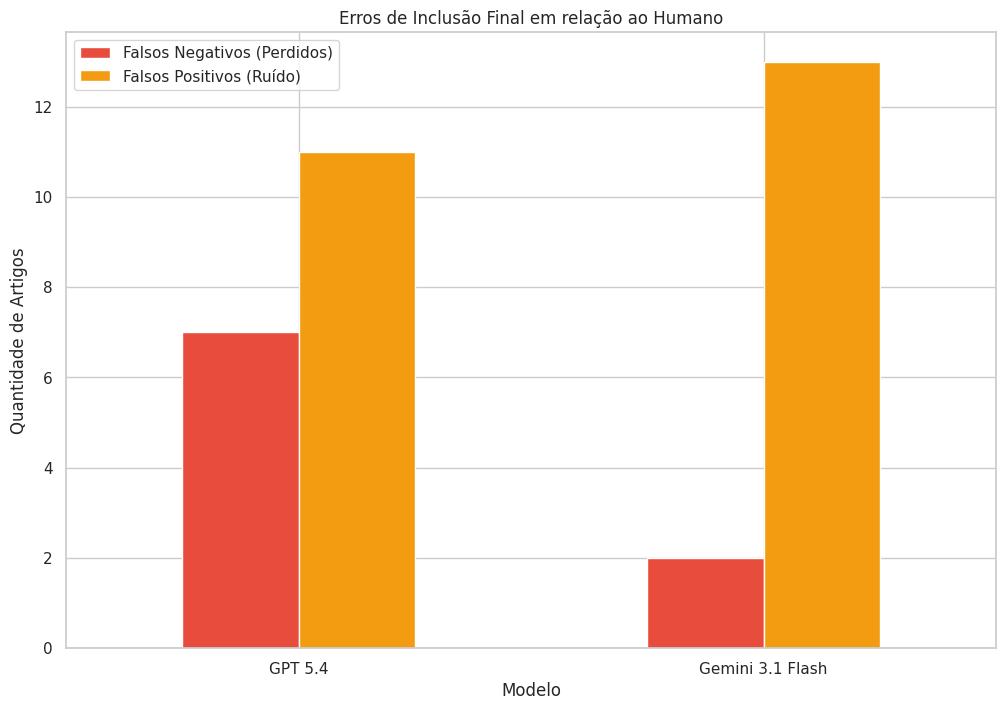

In [11]:
fn_gpt = df_merged[(df_merged['Included_Human'] == True) & (df_merged['Included_GPT'] == False)]
fp_gpt = df_merged[(df_merged['Included_Human'] == False) & (df_merged['Included_GPT'] == True)]

fn_gemini = df_merged[(df_merged['Included_Human'] == True) & (df_merged['Included_Gemini'] == False)]
fp_gemini = df_merged[(df_merged['Included_Human'] == False) & (df_merged['Included_Gemini'] == True)]

error_summary = pd.DataFrame({
    'Modelo': ['GPT 5.4', 'Gemini 3.1 Flash'],
    'Falsos Negativos (Perdidos)': [len(fn_gpt), len(fn_gemini)],
    'Falsos Positivos (Ruído)': [len(fp_gpt), len(fp_gemini)]
})

error_summary.set_index('Modelo').plot(kind='bar', stacked=False, color=['#e74c3c', '#f39c12'])
plt.title("Erros de Inclusão Final em relação ao Humano")
plt.ylabel("Quantidade de Artigos")
plt.xticks(rotation=0)
plt.show()

## Conclusões

- Comparação de acurácia entre GPT e Gemini.
- Análise de qual critério é mais difícil para os modelos.
- Visualização de concordância entre as IAs.